# Exercise 4B

In this exercise, you will learn how to use PCA for dimensionality reduction to visualize clusters and then run a clustering algorithm.

In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [102]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer(as_frame=True).frame

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [104]:
X = df.drop('target', axis=1)

In [119]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


1. Perform scaling `(10 pts)`

In [106]:
## put your answer here
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [107]:
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
X_scaled_df.head(100)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


2. Perform dimensionality reduction using PCA `(10 pts)`

In [108]:
## put your answer here
X_scaled.shape

pca = PCA(n_components=2)
pd.DataFrame
X_reduced = pca.fit_transform(X_scaled)

In [109]:
X_reduced.shape

(569, 2)

3. Get the total explained variance `(5 pts)`

In [110]:
## put your answer here
explained_variance = pca.explained_variance_ratio_

PC_1_explained_variance = explained_variance[0]
PC_2_explained_variance = explained_variance[1]

print("Explained variance of PC1:", PC_1_explained_variance)
print("Explained variance of PC2:", PC_2_explained_variance)
print("Total explained variance: ", explained_variance.sum())

Explained variance of PC1: 0.44272025607526366
Explained variance of PC2: 0.18971182044033078
Total explained variance:  0.6324320765155944


4. Plot the explained variances of each principal component `(5 pts)`

Text(0.5, 1.0, 'Explained Variance by Principal Component')

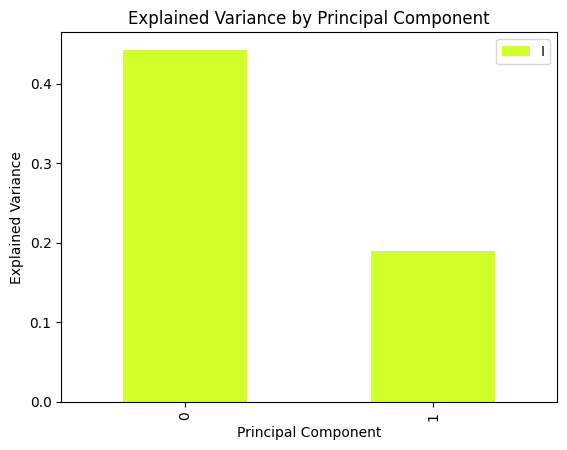

In [121]:
## put your answer here
pd.DataFrame(explained_variance).plot.bar(color="#d2ff28")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.legend("Individual Explained Variance")
plt.title("Explained Variance by Principal Component")

5. Visualize the dataset after PCA using a scatter plot `(5 pts)`

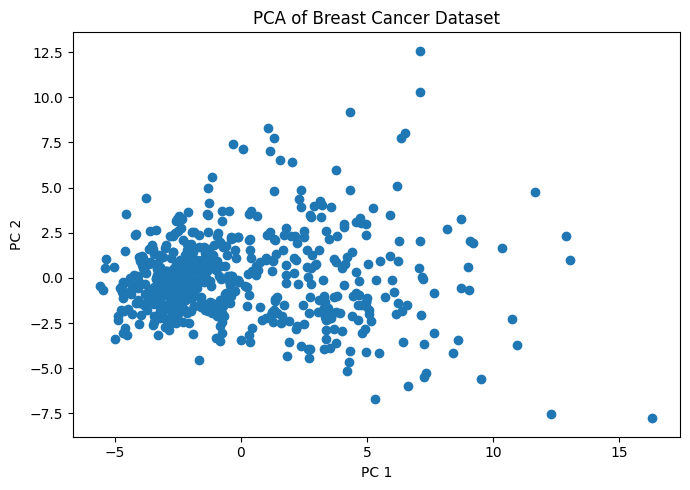

In [112]:
## put your answer here
plt.figure(figsize=(7,5))

plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA of Breast Cancer Dataset")

plt.tight_layout()

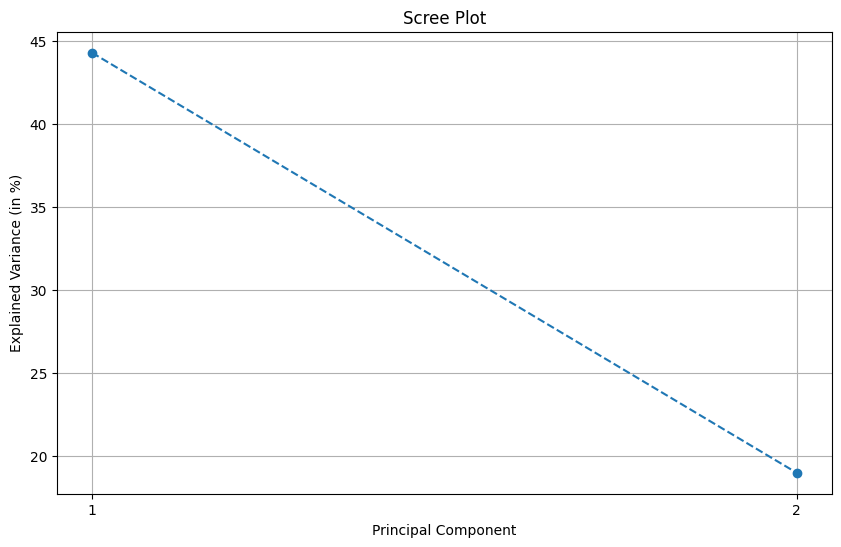

In [113]:
# Trying scree plot
PC_values = np.arange(pca.n_components_) + 1

plt.figure(figsize=(10, 6))
plt.plot(PC_values, explained_variance * 100, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (in %)')
plt.xticks(PC_values) # Ensure all components are labeled on the x-axis
plt.grid(True)
plt.show()


6. Perform clustering using any clustering algorithm `(10 pts)`

In [114]:
# KMeans

kmeans = KMeans(n_clusters=2, init="k-means++", max_iter=300, n_init=10, random_state=0)
kmeans.fit(X_reduced)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_


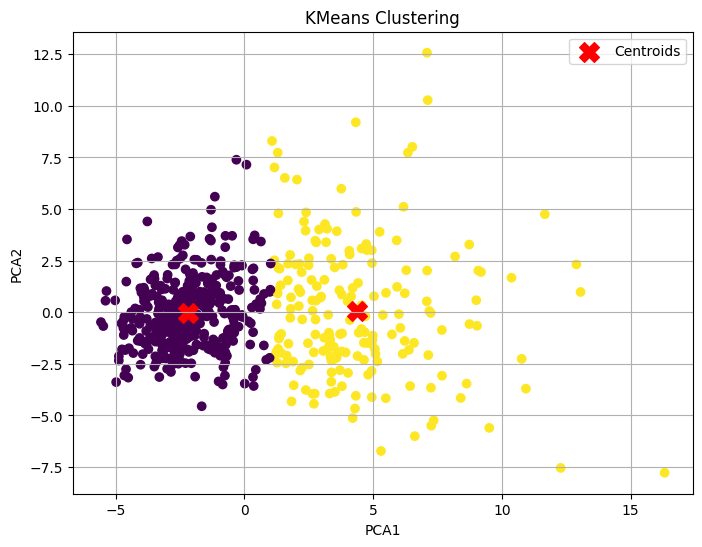

In [115]:
# KMeans

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200, c='red', label='Centroids')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('KMeans Clustering')
plt.legend()
plt.grid(True)
plt.show()

7. View the loading scores of each principal component `(5 pts)`

In [116]:
## put your answer here
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loading_matrix = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=X.columns)
loading_matrix

,PC1,PC2
mean radius,0.798469,-0.558394
mean texture,0.378346,-0.142564
mean perimeter,0.829965,-0.513800
mean area,0.806101,-0.551755
mean smoothness,0.520110,0.444392
mean compactness,0.872817,0.362680
mean concavity,0.942542,0.143660
mean concave points,0.951490,-0.083016
mean symmetry,0.503978,0.454506
mean fractal dimension,0.234772,0.875292


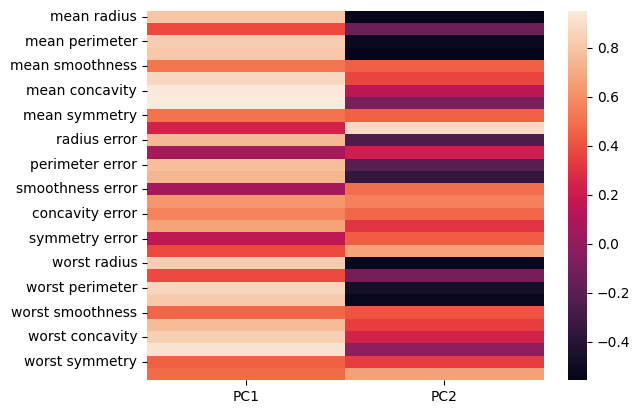

In [117]:
sns.heatmap(loading_matrix)
plt.show()